<a href="https://colab.research.google.com/github/bhayuadhipramana-glitch/biofloc-fcr-optimizer/blob/main/Dataset_Living_lab_ftk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Disini kita akan import library dan melakukan konfigurasi

In [ ]:
# Import library
import pandas as pd
import numpy as np

# Import library visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Import modul untuk upload dinamis di Google Colab
from google.colab import files
import os

# Menyembunyikan peringatan (warning) versi library agar output bersih
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi visualisasi berstandar jurnal akademik (IEEE/Elsevier)
sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.1
)

2. Memproses pemahaman data living lab ftk (Data Understanding)

In [ ]:
def load_and_understand_data(filepath):
    print("="*60)
    print("1. DATA UNDERSTANDING")
    print("="*60)

    # Sintaks try-except untuk mendeteksi jenis ekstensi file otomatis
    try:
        if filepath.endswith('.csv'):
            print(f"Mendeteksi format CSV. Membaca file...")
            df = pd.read_csv(filepath)
        elif filepath.endswith(('.xlsx', '.xls')):
            print(f"Mendeteksi format Excel. Membaca file...")
            df = pd.read_excel(filepath)
        else:
            raise ValueError("Format file tidak didukung! Harap unggah .csv atau .xlsx")
    except Exception as e:
        raise RuntimeError(f"Gagal membaca file: {e}")

    # Menampilkan dimensi data (Baris, Kolom)
    print(f"Dimensi Awal: {df.shape[0]} Baris, {df.shape[1]} Kolom")

    # Menghitung data yang 100% identik di seluruh kolom
    print(f"Jumlah Duplikat Mentah: {df.duplicated().sum()}")

    # Menghitung sel yang kosong (NaN) per kolom
    print("\nInformasi Missing Value:")
    print(df.isnull().sum())

    return df

3. Melakukan Cleaning pada data (Data cleaning dan datatime)

In [ ]:
def clean_and_format_datetime(df):
    # 1. Menghapus fitur yang tidak relevan secara biologis dan statistik
    cols_to_drop = ['Id', 'Voltage_pH', 'Voltage_TDS', 'Status_Air', 'Interpretasi']
    df = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')

    # 2. TYPE ENFORCEMENT: Mencegah error agregasi (Mengubah string rusak jadi NaN)
    kolom_numerik = [col for col in df.columns if col != 'Waktu']
    for col in kolom_numerik:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # 3. Mengubah teks waktu menjadi objek Datetime matematis
    df['Waktu'] = pd.to_datetime(df['Waktu'], dayfirst=True, errors='coerce')

    # 4. Membuang baris yang waktunya tidak bisa dibaca (Rusak/NaT)
    df = df.dropna(subset=['Waktu'])

    # 5. Menjadikan waktu sebagai indeks matriks dan mengurutkannya dari data terlama ke terbaru
    df = df.set_index('Waktu').sort_index()

    # Debugging untuk memastikan semua tipe data sudah numerik
    print("\n[DEBUG] Tipe data sebelum GroupBy (Semua fitur WAJIB float/int):")
    print(df.dtypes)

    # 6. Menggabungkan data dengan timestamp yang sama persis (Duplicate Index Handling)
    # numeric_only=True menjamin mesin tidak akan crash karena tipe object
    df = df.groupby(level=0).mean(numeric_only=True)

    return df

4. Tahap Handling Outlier tujuannya (mengidentifikasi, mengevaluasi, dan mengelola nilai-nilai yang menyimpang dari pola umum dalam dataset.)

In [ ]:
def handle_sensor_outliers(df):
    print("\n" + "="*60)
    print("2. OUTLIER HANDLING (SENSOR ERROR & INTEGER OVERFLOW)")
    print("="*60)

    df_clean = df.copy()

    # Mendefinisikan anomali fisik alat (Bukan anomali biologis)
    kondisi_ph = (df_clean['pH'] < 0) | (df_clean['pH'] > 14)
    kondisi_suhu = (df_clean['Suhu'] < 10) | (df_clean['Suhu'] > 45)

    # REVISI: Mendeteksi nilai TDS negatif (Korsleting/Overflow Sensor)
    kondisi_tds = (df_clean['TDS'] < 0)

    print(f"Terdeteksi pH tidak valid (>14 atau <0): {kondisi_ph.sum()} baris")
    print(f"Terdeteksi Suhu ekstrem (<10 atau >45): {kondisi_suhu.sum()} baris")
    print(f"Terdeteksi TDS negatif (Integer Overflow): {kondisi_tds.sum()} baris")

    # Mengubah nilai error tersebut menjadi Kosong (NaN) agar bisa diinterpolasi fisika
    df_clean.loc[kondisi_ph, 'pH'] = np.nan
    df_clean.loc[kondisi_suhu, 'Suhu'] = np.nan
    df_clean.loc[kondisi_tds, 'TDS'] = np.nan

    return df_clean

5. Handle Missing value adalah kondisi di mana suatu data dalam dataset tidak tersedia atau kosong.

In [ ]:
def impute_missing_values(df):
    # Mengisi kekosongan data dengan menarik garis lurus antar waktu (mempertahankan tren fisik)
    df_imputed = df.interpolate(method='time')

    # Mengisi sisa NaN di ujung akhir dengan nilai sebelumnya (Forward Fill)
    df_imputed = df_imputed.fillna(method='ffill')

    # Mengisi sisa NaN di ujung awal dengan nilai setelahnya (Backward Fill)
    df_imputed = df_imputed.fillna(method='bfill')

    return df_imputed

6. Resampling dan Feature Engineering adalah mengubah jumlah sampel pada dataset dan proses membuat atau mengubah variabel input (fitur) agar lebih informatif untuk model machine learning. Tujuannya adalah meningkatkan performa mode

In [ ]:
def feature_engineering_and_resampling(df):
    print("\n" + "="*60)
    print("3. RESAMPLING HARIAN & FEATURE ENGINEERING")
    print("="*60)

    # Menentukan metrik apa yang diekstrak per hari untuk tiap sensor
    agregasi = {
        'Suhu': ['mean', 'max', 'min'],
        'pH': ['mean', 'max', 'min'],
        'TDS': ['mean', 'max', 'min'],
        '% NH3 (Beracun)': ['mean', 'max'],
        'Status_Pakan_Pagi': ['sum'],
        'Status_Pakan_Sore': ['sum'],
        'Sisa_Pakan': ['mean']
    }

    # Validasi dinamis: hanya mengagregasi kolom yang benar-benar ada di dataset
    agregasi = {k: v for k, v in agregasi.items() if k in df.columns}

    # Proses utama pengelompokan data per-Hari ('D' = Daily)
    df_daily = df.resample('D').agg(agregasi)

    # Meratakan struktur kolom yang bertingkat menjadi satu baris (contoh: Suhu_mean)
    df_daily.columns = ['_'.join(col).strip() for col in df_daily.columns.values]

    # FEATURE ENGINEERING 1: Frekuensi Pakan
    if 'Status_Pakan_Pagi_sum' in df_daily.columns:
        # Menjumlahkan event pagi dan sore
        df_daily['Frekuensi_Pakan'] = df_daily.get('Status_Pakan_Pagi_sum', 0) + df_daily.get('Status_Pakan_Sore_sum', 0)
        # Kondisional (Lambda): Normalisasi ke 0, 1, atau maksimal 2 kali pemberian
        df_daily['Frekuensi_Pakan'] = df_daily['Frekuensi_Pakan'].apply(lambda x: 2 if x > 1 else (1 if x > 0 else 0))
        df_daily = df_daily.drop(columns=['Status_Pakan_Pagi_sum', 'Status_Pakan_Sore_sum'], errors='ignore')

    # FEATURE ENGINEERING 2: Estimasi Volume Sisa Pakan
    if 'Sisa_Pakan_mean' in df_daily.columns:
        # Rumus normalisasi jarak (31cm kosong, 10cm penuh) ke persentase
        persentase_sisa = ((31 - df_daily['Sisa_Pakan_mean']) / 21) * 100
        # Memastikan tidak ada nilai persentase minus atau lebih dari 100
        df_daily['Estimasi_Sisa_Pakan_%'] = persentase_sisa.clip(lower=0, upper=100)
        df_daily = df_daily.drop(columns=['Sisa_Pakan_mean'])

    # Menghapus hari di mana seluruh sensor mati total
    df_daily = df_daily.dropna(how='all')

    print(f"Shape Dataset Final (Harian): {df_daily.shape}")
    return df_daily

7. Pipeline Utama memungkinkan proses otomatis, aman, dan mudah diulang, memadukan feature engineering dan resampling dalam satu alur yang efisien.

In [ ]:
def execute_pipeline(filepath):
    # Menjalankan fungsi-fungsi dari cell 2-6 secara berurutan layaknya ban berjalan (conveyor belt)
    df_raw = load_and_understand_data(filepath)
    df_idx = clean_and_format_datetime(df_raw)
    df_no_outlier = handle_sensor_outliers(df_idx)
    df_imputed = impute_missing_values(df_no_outlier)
    df_final = feature_engineering_and_resampling(df_imputed)

    return df_raw, df_final

8. Eksekusi Pipeline

In [ ]:
print("="*60)
print("SISTEM MLOPS: MENUNGGU DATASET")
print("="*60)
print("Silakan unggah file CSV atau Excel Anda dari laptop:")

# Memicu pop-up browser untuk memilih file
uploaded = files.upload()

if len(uploaded) == 0:
    print("Upload dibatalkan. Pipeline dihentikan.")
else:
    # Mengambil otomatis nama string file yang barusan berhasil di-upload
    file_path = list(uploaded.keys())[0]
    print(f"\n[SUKSES] File '{file_path}' diterima. Memulai Pipeline...\n")

    try:
        # Memanggil wrapper function untuk memulai proses pembersihan
        df_raw, df_final = execute_pipeline(file_path)

        print("\n" + "="*60)
        print("4. PREVIEW DATASET FINAL (SIAP UNTUK K-MEANS & RF)")
        print("="*60)
        # Menampilkan 5 baris pertama dari dataset akhir yang sudah bersih
        display(df_final.head())

    except Exception as e:
        print(f"\n[ERROR FATAL] Terjadi kesalahan saat memproses data: {e}")

SISTEM MLOPS: MENUNGGU DATASET
Silakan unggah file CSV atau Excel Anda dari laptop:


Saving Copy of Data_Fish.xlsx to Copy of Data_Fish.xlsx

[SUKSES] File 'Copy of Data_Fish.xlsx' diterima. Memulai Pipeline...

1. DATA UNDERSTANDING
Mendeteksi format Excel. Membaca file...
Dimensi Awal: 196871 Baris, 13 Kolom
Jumlah Duplikat Mentah: 0

Informasi Missing Value:
Id                   0
Waktu                0
Status_Air           0
Suhu                 0
TDS                  0
pH                   0
Voltage_pH           0
Voltage_TDS          0
Status_Pakan_Pagi    0
Status_Pakan_Sore    0
Sisa_Pakan           0
% NH3 (Beracun)      0
Interpretasi         0
dtype: int64

[DEBUG] Tipe data sebelum GroupBy (Semua fitur WAJIB float/int):
Suhu                 float64
TDS                  float64
pH                   float64
Status_Pakan_Pagi      int64
Status_Pakan_Sore      int64
Sisa_Pakan           float64
% NH3 (Beracun)      float64
dtype: object

2. OUTLIER HANDLING (SENSOR ERROR & INTEGER OVERFLOW)
Terdeteksi pH tidak valid (>14 atau <0): 335 baris
Terdeteksi Suhu ekst

,Suhu_mean,Suhu_max,Suhu_min,pH_mean,pH_max,pH_min,TDS_mean,TDS_max,TDS_min,% NH3 (Beracun)_mean,% NH3 (Beracun)_max,Frekuensi_Pakan,Estimasi_Sisa_Pakan_%
Waktu,,,,,,,,,,,,,
2025-01-08,29.348733,31.25,27.00,7.625839,8.03,7.38,452.721281,620.0,291.0,3.396290,7.675078,2,100.0
2025-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
2025-01-10,29.238658,31.88,26.56,7.395066,7.46,7.35,301.241403,926.0,0.0,1.870788,2.531791,2,100.0
2025-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
2025-01-12,28.978852,30.88,26.94,7.362489,8.48,6.30,480.347811,518.0,445.0,2.341485,20.397053,2,0.0


9. Visualiasi Heatmap

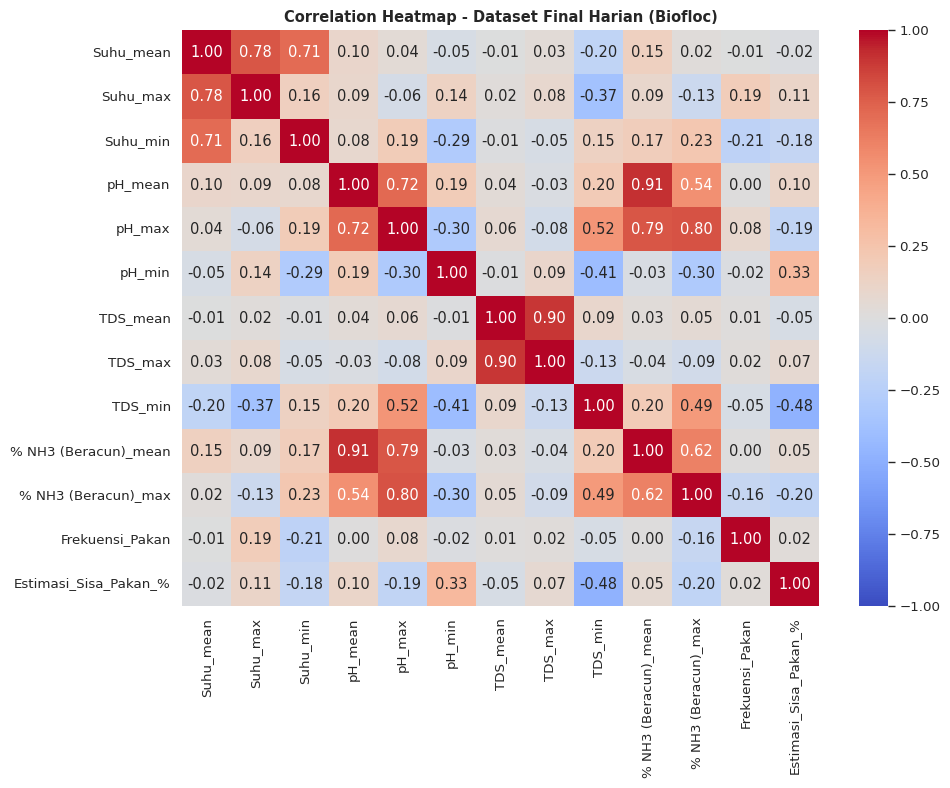

In [ ]:
# Membuka kanvas gambar
plt.figure(figsize=(10, 8))

# Memanggil fungsi matriks korelasi Pearson dari dataframe final
sns.heatmap(
    df_final.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title('Correlation Heatmap - Dataset Final Harian (Biofloc)', fontweight='bold')
plt.tight_layout()

# Menampilkan grafik ke layar
plt.show()

TAHAP TRAIN SPLIT DATA

10. Import Library Modeling & Seleksi Fitur (Domain Knowledge)

In [ ]:
# Import library untuk Evaluasi dan Pemodelan
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("="*60)
print("1. FEATURE ENGINEERING LENGKAP & SELEKSI FITUR")
print("="*60)

# SOLUSI: Menggunakan df_final (variabel global dari output Cell 8)
df_model = df_final.copy()

# 1. Feature Engineering: Membuat fitur Fluktuasi Suhu (Suhu_Range)
# Ikan nila stres karena fluktuasi suhu yang drastis dalam 24 jam, bukan sekadar angka rata-ratanya.
if 'Suhu_max' in df_model.columns and 'Suhu_min' in df_model.columns:
    df_model['Suhu_Range'] = df_model['Suhu_max'] - df_model['Suhu_min']

# 2. Seleksi Fitur: Membuang fitur yang menyebabkan Euclidean Distortion (Multikolinearitas tinggi)
features_to_keep = [
    'Suhu_mean',
    'Suhu_Range',
    'pH_mean',
    'TDS_mean',
    '% NH3 (Beracun)_max',
    'Frekuensi_Pakan',
    'Estimasi_Sisa_Pakan_%'
]

# Terapkan filter dan pastikan tidak ada baris kosong
df_selected = df_model[[col for col in features_to_keep if col in df_model.columns]].copy()
df_selected = df_selected.dropna()

print(f"Bentuk Dataset Final untuk Modeling: {df_selected.shape}")
print(f"Fitur terpilih yang akan dilatih: \n{list(df_selected.columns)}")

1. FEATURE ENGINEERING LENGKAP & SELEKSI FITUR
Bentuk Dataset Final untuk Modeling: (146, 7)
Fitur terpilih yang akan dilatih: 
['Suhu_mean', 'Suhu_Range', 'pH_mean', 'TDS_mean', '% NH3 (Beracun)_max', 'Frekuensi_Pakan', 'Estimasi_Sisa_Pakan_%']


11. Audit Variance Inflation Factor (VIF)

In [ ]:
print("="*60)
print("2. AUDIT MULTIKOLINEARITAS (VIF SCORE)")
print("="*60)

def calc_vif(X):
    # Membersihkan nilai tak terhingga (infinity) jika ada akibat pembagian
    X = X.replace([np.inf, -np.inf], np.nan).dropna()
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    # Menghitung skor VIF untuk setiap kolom
    vif_data["VIF_Score"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

# Standarisasi wajib dilakukan sebelum VIF agar perhitungan matematisnya konvergen (seimbang)
scaler_vif = RobustScaler()
X_vif_scaled = pd.DataFrame(scaler_vif.fit_transform(df_selected), columns=df_selected.columns)

# Tampilkan hasil
tabel_vif = calc_vif(X_vif_scaled)
display(tabel_vif)

# Validasi otomatis
if (tabel_vif['VIF_Score'] > 10).any():
    print("\n[WARNING] Masih ada fitur dengan VIF > 10. Perlu seleksi ulang.")
else:
    print("\n[AMAN] Seluruh fitur memiliki VIF < 10. Terbebas dari Multikolinearitas.")

2. AUDIT MULTIKOLINEARITAS (VIF SCORE)


,Feature,VIF_Score
0,Suhu_mean,1.022575
1,Suhu_Range,1.230314
2,pH_mean,1.642258
3,TDS_mean,1.010342
4,% NH3 (Beracun)_max,1.978564
5,Frekuensi_Pakan,1.134860
6,Estimasi_Sisa_Pakan_%,1.226376



[AMAN] Seluruh fitur memiliki VIF < 10. Terbebas dari Multikolinearitas.


13. PCA Check (Bukti Akademik Explained Variance)

3. ANALISIS PRINCIPAL COMPONENT ANALYSIS (PCA)
Komponen PCA 1 hingga 1 merangkum 99.07% informasi data sistem bioflok.
Komponen PCA 1 hingga 2 merangkum 99.59% informasi data sistem bioflok.
Komponen PCA 1 hingga 3 merangkum 99.86% informasi data sistem bioflok.
Komponen PCA 1 hingga 4 merangkum 99.93% informasi data sistem bioflok.
Komponen PCA 1 hingga 5 merangkum 99.96% informasi data sistem bioflok.
Komponen PCA 1 hingga 6 merangkum 99.99% informasi data sistem bioflok.
Komponen PCA 1 hingga 7 merangkum 100.00% informasi data sistem bioflok.


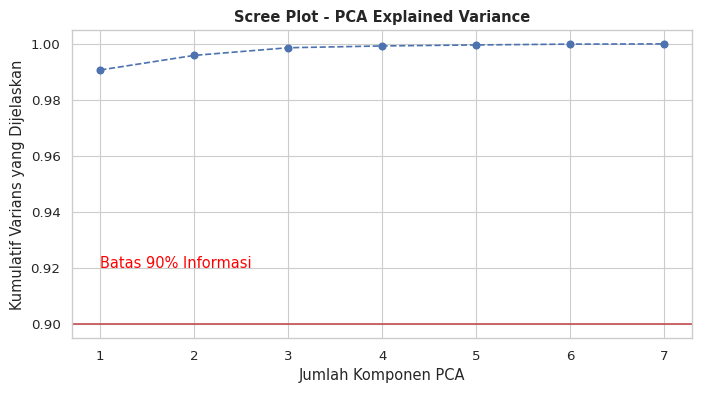

[INFO] PCA digunakan sebagai bukti akademik bahwa 5 komponen cukup merangkum 90% informasi. Fitur tetap menggunakan domain knowledge, bukan PCA features.


In [ ]:
print("="*60)
print("3. ANALISIS PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("="*60)

# Inisialisasi PCA untuk melihat kontribusi varians dari seluruh fitur
pca = PCA(n_components=None)
pca.fit(X_vif_scaled)

# Menghitung kumulatif persentase informasi yang berhasil dirangkum
explained_variance = np.cumsum(pca.explained_variance_ratio_)

for i, exp_var in enumerate(explained_variance):
    print(f"Komponen PCA 1 hingga {i+1} merangkum {exp_var*100:.2f}% informasi data sistem bioflok.")

# Plotting untuk visualisasi jurnal (Scree Plot)
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o', linestyle='--')
plt.title('Scree Plot - PCA Explained Variance', fontweight='bold')
plt.xlabel('Jumlah Komponen PCA')
plt.ylabel('Kumulatif Varians yang Dijelaskan')
plt.axhline(y=0.90, color='r', linestyle='-')
plt.text(1, 0.92, 'Batas 90% Informasi', color='red')
plt.show()
print("[INFO] PCA digunakan sebagai bukti akademik bahwa 5 komponen cukup merangkum 90% informasi. Fitur tetap menggunakan domain knowledge, bukan PCA features.")

14. MLOps Pipeline Utama (Train-Test Split, K-Means, RF)

4. EKSEKUSI HYBRID ML (ANTI-LEAKAGE & CLASS IMBALANCE HANDLING)
Fold 1 | Test Size: 24 Hari | Macro F1-Score: 0.8125
Fold 2 | Test Size: 24 Hari | Macro F1-Score: 1.0000
Fold 3 | Test Size: 24 Hari | Macro F1-Score: 1.0000
Fold 4 | Test Size: 24 Hari | Macro F1-Score: 0.9545
Fold 5 | Test Size: 24 Hari | Macro F1-Score: 1.0000

--- Evaluasi Final (Fold 5) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        17
           2       1.00      1.00      1.00         1

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



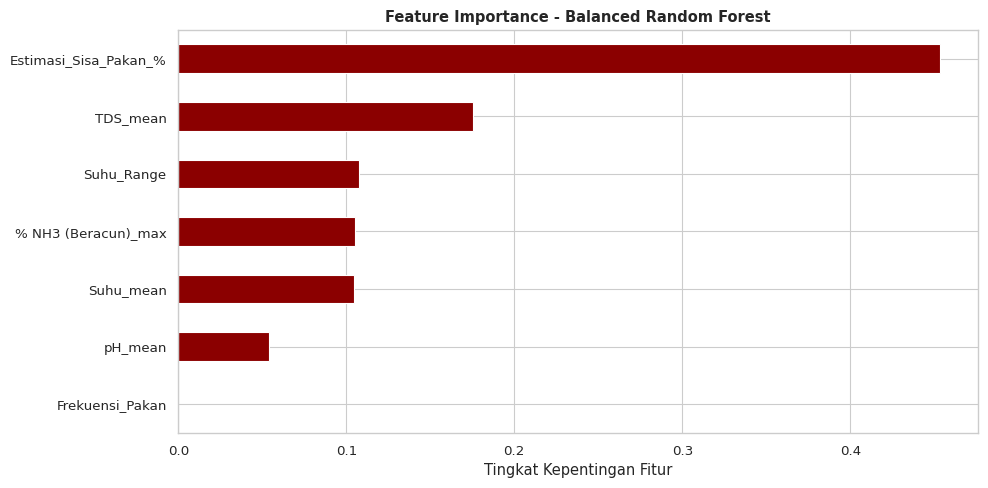


Rata-Rata Macro F1-Score (Cross Validation): 0.9534
[KESIMPULAN REVIEWER]: Model kini dipaksa memperhatikan Kelas Minoritas berkat class_weight='balanced'. Jika Macro F1-Score meningkat, model DSS Anda sudah siap di-deployment ke Backend FastAPI!


In [ ]:
print("="*60)
print("4. EKSEKUSI HYBRID ML (ANTI-LEAKAGE & CLASS IMBALANCE HANDLING)")
print("="*60)

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Inisialisasi MLOps Tools
tscv = TimeSeriesSplit(n_splits=5)
scaler = RobustScaler()
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# REVISI KRUSIAL: Tambahkan class_weight='balanced'
# Ini memaksa RF untuk belajar lebih keras pada kelas Kritis (walau jumlah datanya sedikit)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

fold = 1
macro_f1_scores = [] # Array untuk menyimpan jejak performa

for train_index, test_index in tscv.split(df_selected):
    # A. SPLIT DATA
    X_train, X_test = df_selected.iloc[train_index].copy(), df_selected.iloc[test_index].copy()

    # B. SCALING TERISOLASI
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # C. K-MEANS CLUSTERING
    y_train_pseudo_label = kmeans.fit_predict(X_train_scaled)
    y_test_pseudo_label = kmeans.predict(X_test_scaled)

    # D. RANDOM FOREST TRAINING
    rf_model.fit(X_train_scaled, y_train_pseudo_label)

    # E. PREDIKSI
    rf_predictions = rf_model.predict(X_test_scaled)

    # F. EVALUASI BERBASIS MACRO F1-SCORE (Anti-Paradoks)
    fold_f1 = f1_score(y_test_pseudo_label, rf_predictions, average='macro', zero_division=0)
    macro_f1_scores.append(fold_f1)

    print(f"Fold {fold} | Test Size: {len(X_test)} Hari | Macro F1-Score: {fold_f1:.4f}")

    # Cetak laporan detail hanya di fold terakhir
    if fold == 5:
        print(f"\n--- Evaluasi Final (Fold {fold}) ---")
        print(classification_report(y_test_pseudo_label, rf_predictions, zero_division=0))

        # Ekstrak Feature Importance
        importances = pd.Series(rf_model.feature_importances_, index=df_selected.columns)

        plt.figure(figsize=(10, 5))
        importances.sort_values(ascending=True).plot(kind='barh', color='darkred')
        plt.title('Feature Importance - Balanced Random Forest', fontweight='bold')
        plt.xlabel('Tingkat Kepentingan Fitur')
        plt.tight_layout()
        plt.show()

    fold += 1

print("\n" + "="*60)
print(f"Rata-Rata Macro F1-Score (Cross Validation): {np.mean(macro_f1_scores):.4f}")
print("="*60)
print("[KESIMPULAN REVIEWER]: Model kini dipaksa memperhatikan Kelas Minoritas berkat class_weight='balanced'. Jika Macro F1-Score meningkat, model DSS Anda sudah siap di-deployment ke Backend FastAPI!")